# IRI full trigger modeling

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar
import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.constants import *

In [3]:
blob_name = f"{PROJECT_PREFIX}/processed/iri_cerf_stats.parquet"
df_stats_iri = stratus.load_parquet_from_blob(blob_name)

In [4]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/chirps/chirps_dek_season_cumul.parquet"
)
df_chirps_raw = stratus.load_parquet_from_blob(blob_name)

In [5]:
df_chirps_final = df_chirps_raw[df_chirps_raw["dekad_overall"] == 27]

In [6]:
df_stats_iri = df_stats_iri.merge(
    df_chirps_final[["year", "rfh_all_cumul", "rfh_aoi_cumul"]]
)

In [11]:
start_year = 2001
end_year = 2025
total_years = end_year - start_year + 1

In [12]:
rp_target = 4
n_years_overall_target = int((total_years + 1) / rp_target)

In [13]:
n_years_overall_target

6

In [15]:
actual_rp = (total_years + 1) / n_years_overall_target
actual_rp

4.333333333333333

In [64]:
df_stats_iri[df_stats_iri["year"] >= start_year].sort_values("rfh_all_cumul")

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$,rfh_all_cumul,rfh_aoi_cumul,trigger_obsv,trig_obsv
11,2002,32.4,34.3,40.5,34.2,38.1,35.1,7.0,None,60.4,0.0,NaN,58.278898,197.796330,True,True
28,2019,22.7,28.4,32.4,33.0,30.2,32.8,8.0,None,63.3,0.0,0.0,60.968869,174.521821,True,True
20,2011,36.5,35.9,26.9,41.0,35.0,27.5,2.0,Bad,63.5,1.0,4005971.0,61.178384,194.645161,True,True
26,2017,30.7,39.1,35.4,35.9,31.8,24.8,6.0,None,64.7,0.0,3975873.0,62.546641,206.154328,False,True
23,2014,30.8,35.3,42.2,40.8,39.2,29.7,4.0,None,67.3,0.0,2532163.0,64.870469,256.714735,False,True
13,2004,32.8,29.3,34.5,33.9,35.4,34.2,16.0,None,69.8,0.0,NaN,67.242343,261.750161,False,False
30,2021,20.9,14.9,18.3,19.6,18.7,21.2,10.0,None,70.0,0.0,0.0,67.317151,239.623656,False,False
15,2006,32.1,40.5,31.5,37.1,26.7,30.9,16.0,None,69.5,0.0,NaN,67.421616,170.790007,False,False
16,2007,30.2,27.5,23.7,27.6,20.3,30.5,12.0,None,72.3,0.0,1132595.0,69.543775,259.676785,False,False
14,2005,29.3,35.4,30.6,32.4,27.5,28.1,16.0,None,72.0,0.0,NaN,69.665740,248.051235,False,False


In [65]:
quantiles = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]

In [66]:
mos = [2, 3, 4, 5]

In [70]:
dfs = []
for quantile in quantiles:
    df_q = pd.DataFrame(columns=["year"])
    for mo in mos:
        col = calendar.month_abbr[mo]
        dicts = []
        for current_year in range(start_year, 2026):
            df_past = df_stats_iri[df_stats_iri["year"] <= current_year]
            if df_past.empty:
                continue

            current_row = df_stats_iri.set_index("year").loc[current_year]

            thresh = df_past[col].quantile(1 - quantile)
            trig = current_row[col] >= thresh

            dicts.append(
                {
                    "year": current_year,
                    f"thresh_{mo}": thresh,
                    f"trig_{mo}": trig,
                }
            )

        df_wf_trigs = pd.DataFrame(dicts)
        df_q = df_q.merge(df_wf_trigs, on="year", how="outer")
    df_q["q"] = quantile

    consec_cols = []
    for second_mo in mos[1:]:
        first_mo = second_mo - 1
        consec_col = f"trig_{first_mo}_{second_mo}"
        df_q[consec_col] = df_q[f"trig_{first_mo}"] & df_q[f"trig_{second_mo}"]
        consec_cols.append(consec_col)

    df_q["trig_fcast"] = df_q[consec_cols].any(axis=1)
    dfs.append(df_q)

df_qs = pd.concat(dfs, ignore_index=True)
df_qs = df_qs.merge(df_stats_iri[["year", "rfh_all_cumul"]])

In [68]:
df_qs["trig_either"] = df_qs[["trig_fcast", "trig_obsv"]].any(axis=1)

In [87]:
dicts = []
for quantile, group in df_qs.groupby("q"):
    print(quantile)
    for obsv_trigger_years in range(n_years_overall_target, 0, -1):
        group["trig_obsv"] = (
            group["rfh_all_cumul"]
            <= group["rfh_all_cumul"].nsmallest(obsv_trigger_years).max()
        )
        group["trig_either"] = group[["trig_fcast", "trig_obsv"]].any(axis=1)
        count_trig = group["trig_either"].sum()
        if count_trig == n_years_overall_target:
            for w in ["fcast", "obsv", "either"]:
                col = f"trig_{w}"
                print(group[col].sum())
                print(group[group[col]]["year"].unique())
            dicts.append(
                {
                    "q": quantile,
                    "n_fcast": group["trig_fcast"].sum(),
                    "n_obsv": group["trig_obsv"].sum(),
                }
            )
            break
    print()

0.1
0
[]
6
[2002 2004 2011 2014 2017 2019]
6
[2002 2004 2011 2014 2017 2019]

0.15
0
[]
6
[2002 2004 2011 2014 2017 2019]
6
[2002 2004 2011 2014 2017 2019]

0.2
1
[2014]
6
[2002 2004 2011 2014 2017 2019]
6
[2002 2004 2011 2014 2017 2019]

0.25
2
[2014 2017]
6
[2002 2004 2011 2014 2017 2019]
6
[2002 2004 2011 2014 2017 2019]

0.3
3
[2014 2015 2017]
5
[2002 2011 2014 2017 2019]
6
[2002 2011 2014 2015 2017 2019]

0.35
4
[2009 2014 2015 2017]
2
[2002 2019]
6
[2002 2009 2014 2015 2017 2019]

0.4



In [88]:
df_counts = pd.DataFrame(dicts)

<Axes: xlabel='q'>

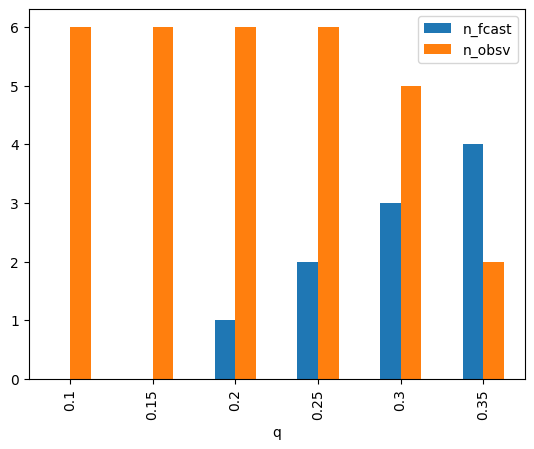

In [91]:
df_counts.set_index("q").plot.bar()

In [92]:
sel_q = 0.3

In [93]:
df_sel_q = df_qs[df_qs["q"] == sel_q]

In [117]:
obsv_trig_year_count = 5

In [118]:
obsv_final_thresh = (
    df_sel_q["rfh_all_cumul"].nsmallest(obsv_trig_year_count).max()
)

In [119]:
obsv_trig_years = df_sel_q[df_sel_q["rfh_all_cumul"] <= obsv_final_thresh][
    "year"
].unique()

In [120]:
obsv_trig_years

array([2002, 2011, 2014, 2017, 2019])

In [95]:
def highlight_true(val):
    if isinstance(val, bool) and val is True:
        return "background-color: crimson"
    return ""

In [99]:
df_disp = df_sel_q.copy()
df_disp = df_disp.sort_values("year", ascending=False)
df_disp.set_index("year")[
    [x for x in df_disp.columns if "trig_" in x]
].style.map(highlight_true)

,trig_2,trig_3,trig_4,trig_5,trig_2_3,trig_3_4,trig_4_5,trig_fcast
year,,,,,,,,
2025,False,False,False,False,False,False,False,False
2024,False,False,False,False,False,False,False,False
2023,False,True,False,False,False,False,False,False
2022,False,False,False,False,False,False,False,False
2021,False,False,False,False,False,False,False,False
2020,False,False,False,False,False,False,False,False
2019,False,False,False,False,False,False,False,False
2018,False,False,False,False,False,False,False,False
2017,True,True,False,False,True,False,False,True


In [100]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/chirps/chirps_dek_season_cumul.parquet"
)
df_chirps_raw = stratus.load_parquet_from_blob(blob_name)

In [101]:
df_dek = df_chirps_raw[
    (df_chirps_raw["year"] <= end_year) & (df_chirps_raw["year"] >= start_year)
].copy()

In [114]:
df_chirps_final = df_dek[df_dek["dekad_overall"] == 27]

In [115]:
df_chirps_final.sort_values("rfh_all_cumul")

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall
197,2002-09-21,6.587397,13.595193,2002,58.278898,197.796330,3,27
350,2019-09-21,5.632800,16.846300,2019,60.968869,174.521821,3,27
278,2011-09-21,5.701405,35.481973,2011,61.178384,194.645161,3,27
332,2017-09-21,8.003728,23.851360,2017,62.546641,206.154328,3,27
305,2014-09-21,5.446877,28.088552,2014,64.870469,256.714735,3,27
215,2004-09-21,3.601224,11.997470,2004,67.242343,261.750161,3,27
368,2021-09-21,3.371929,7.050601,2021,67.317151,239.623656,3,27
233,2006-09-21,3.758882,3.810879,2006,67.421616,170.790007,3,27
242,2007-09-21,2.872027,4.709677,2007,69.543775,259.676785,3,27
224,2005-09-21,10.788594,45.595826,2005,69.665740,248.051235,3,27


In [122]:
df_dek["obsv_target"] = df_dek["year"].isin(obsv_trig_years)

In [175]:
dicts = []
for dekad, group in df_dek.groupby("dekad_overall"):
    for _trig_years in range(obsv_trig_year_count, -1, -1):
        _thresh_upper = group["rfh_all_cumul"].nsmallest(_trig_years + 1).max()
        _thresh_lower = group["rfh_all_cumul"].nsmallest(_trig_years).max()
        _thresh = (_thresh_upper + _thresh_lower) / 2
        group["_trigger"] = group["rfh_all_cumul"] <= _thresh
        fp = group["_trigger"] & ~group["obsv_target"]
        if not fp.any():
            df_stats_iri[f"d{dekad}_trig"] = df_stats_iri["year"].isin(
                group[group["_trigger"]]["year"].unique()
            )
            dicts.append(
                {
                    "dekad": dekad,
                    "thresh": _thresh,
                    "thresh_upper": _thresh_upper,
                    "thresh_lower": _thresh_lower,
                    "n_years": _trig_years,
                }
            )
            break

df_threshs = pd.DataFrame(dicts)

In [176]:
df_threshs

,dekad,thresh,thresh_upper,thresh_lower,n_years
0,19,NaN,2.213521,NaN,0
1,20,6.630519,7.415663,5.845375,2
2,21,13.555627,14.156628,12.954625,5
3,22,22.570942,23.845681,21.296203,5
4,23,31.899764,32.602782,31.196745,3
5,24,41.703811,41.724218,41.683405,2
6,25,50.951064,51.226068,50.676061,5
7,26,57.177062,58.877146,55.476979,4
8,27,66.056406,67.242343,64.870469,5


In [126]:
cols = [f"d{x}_trig" for x in range(19, 28)]

In [131]:
df_stats_iri[df_stats_iri["year"] >= start_year].sort_values(
    "year", ascending=False
).set_index("year")[cols].style.map(highlight_true)

,d19_trig,d20_trig,d21_trig,d22_trig,d23_trig,d24_trig,d25_trig,d26_trig,d27_trig
year,,,,,,,,,
2025,False,False,False,False,False,False,False,False,False
2024,False,False,False,False,False,False,False,False,False
2023,False,False,False,False,False,False,False,False,False
2022,False,False,False,False,False,False,False,False,False
2021,False,False,False,False,False,False,False,False,False
2020,False,False,False,False,False,False,False,False,False
2019,False,True,True,True,True,True,True,True,True
2018,False,False,False,False,False,False,False,False,False
2017,False,False,True,True,True,False,True,True,True


In [172]:
df_disp = df_sel_q.merge(df_stats_iri)
df_disp = df_disp.sort_values("year", ascending=False)

fcast_col = "Déclenche<br>prévisions"
obsv_col = "Déclenche<br>observations"
badyears_col = "Classement de<br>mauvaises années"
cerf_col = "Montant allocation<br>CERF (USD)"

col_rename = {
    "Humanitarian Bad Years (rank)": badyears_col,
    "Amount in US$": cerf_col,
    "trig_fcast": fcast_col,
    "d27_trig": obsv_col,
}

trig_cols = [fcast_col, obsv_col]
numeric_cols = [badyears_col, cerf_col]
cols = trig_cols + numeric_cols

df_disp = df_disp.rename(columns=col_rename)

sty = (
    df_disp.set_index("year")[cols]
    .style.map(highlight_true, subset=trig_cols)
    .format(
        {
            badyears_col: "{:,.0f}",
            cerf_col: "{:,.0f}",
        },
        na_rep="",
    )
    .background_gradient(cmap="Purples_r", subset=[badyears_col])
    .background_gradient(cmap="Reds", subset=[cerf_col])
    # override NaNs
    .map(
        lambda v: "background-color: white;" if pd.isna(v) else "",
        subset=numeric_cols,
    )
)

sty

,Déclencheprévisions,Déclencheobservations,Classement demauvaises années,Montant allocationCERF (USD)
year,,,,
2025,False,False,,0
2024,False,False,30,0
2023,False,False,30,0
2022,False,False,30,0
2021,False,False,10,0
2020,False,False,16,0
2019,False,True,8,0
2018,False,False,30,0
2017,True,True,6,"3,975,873"


In [132]:
df_dek = df_dek.merge(
    df_threshs.rename(columns={"dekad": "dekad_overall"}), how="left"
)

In [133]:
df_dek["obsv_trig"] = df_dek["rfh_all_cumul"] <= df_dek["thresh"]

[None, None]

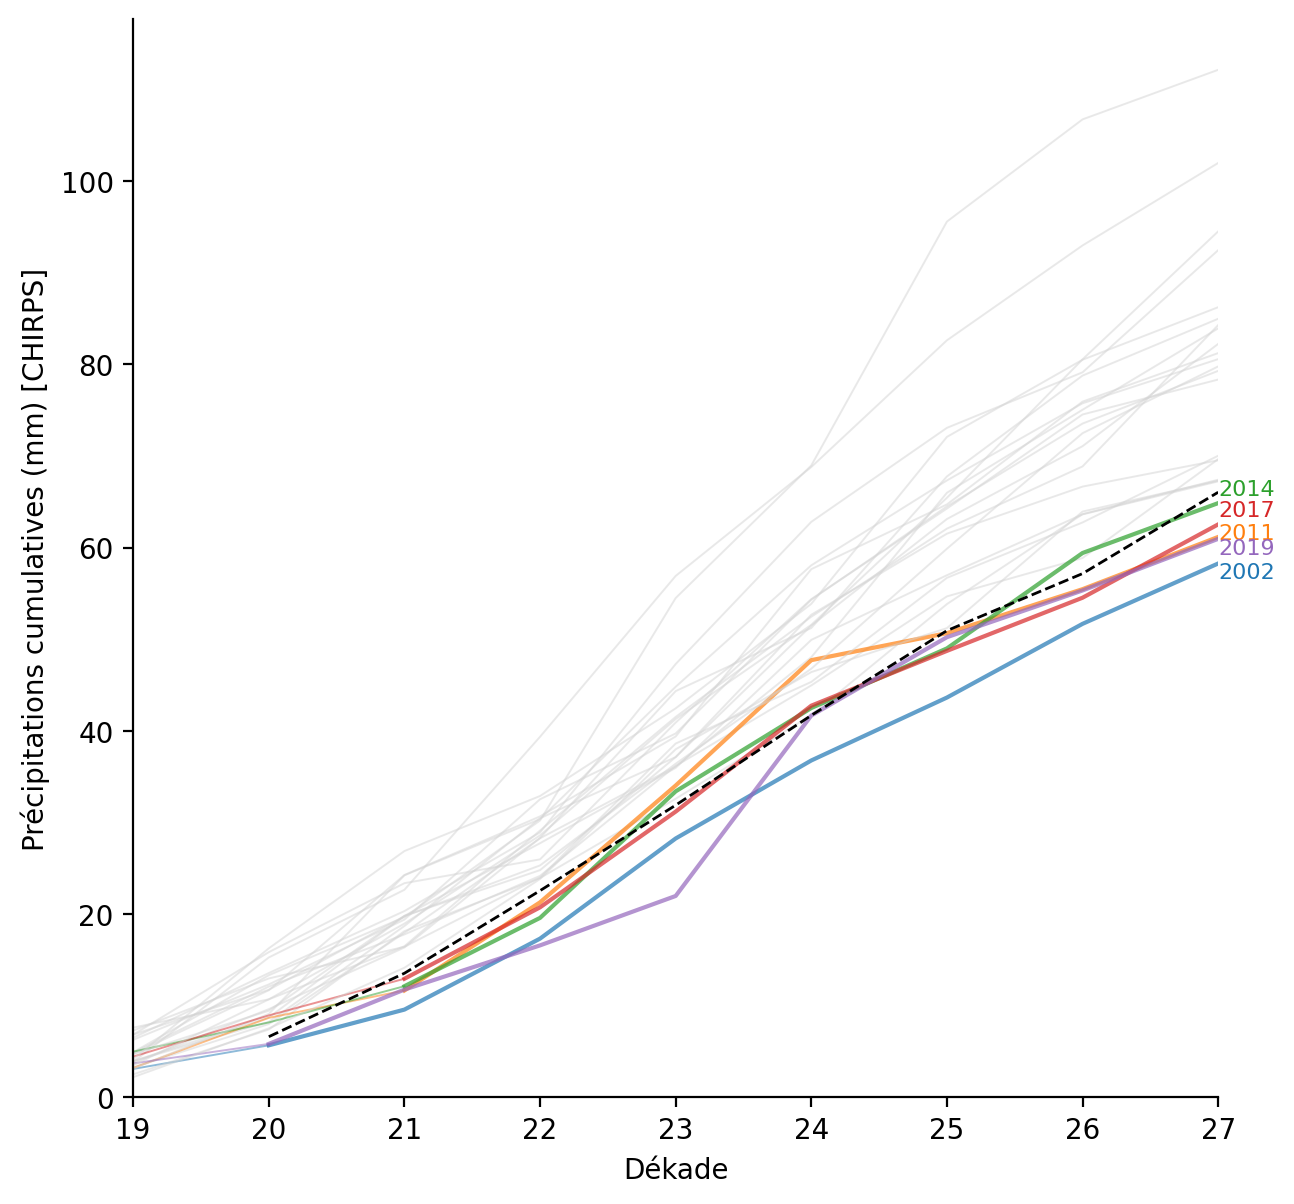

In [148]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

col = "rfh_all_cumul"

cmap = plt.cm.tab10
color_idx = 0

year_colors = {}  # store colors for triggered years

for year, group in df_dek.groupby("year"):

    first_dek_trig = group[group["obsv_trig"]]["dekad_overall"].min()
    any_trig = group["obsv_trig"].any()

    if any_trig:
        color = cmap(color_idx % cmap.N)
        year_colors[year] = color
        color_idx += 1
    else:
        color = "lightgrey"

    if any_trig:
        group_trig = group[group["dekad_overall"] >= first_dek_trig]
        group_notrig = group[group["dekad_overall"] <= first_dek_trig]
    else:
        group_trig = group.iloc[0:0]
        group_notrig = group

    if len(group_trig):
        group_trig.plot(
            x="dekad_overall",
            y=col,
            ax=ax,
            color=color,
            alpha=0.7,
            linewidth=1.5,
        )

    group_notrig.plot(
        x="dekad_overall",
        y=col,
        ax=ax,
        color=color,
        alpha=0.5,
        linewidth=0.7,
    )

df_threshs.plot(
    x="dekad",
    y="thresh",
    ax=ax,
    color="k",
    linewidth=1,
    linestyle="--",
)

# ---- annotate years on right edge ----

x_text = 27  # slightly beyond axis limit

y_adj = {2002: -1, 2019: -1, 2014: 1.5, 2017: 1.5, 2011: 0.4}

for year, color in year_colors.items():
    group = df_dek[df_dek["year"] == year]

    # get last dekad value within plotting window
    last_row = group[group["dekad_overall"] == 27]

    if not last_row.empty:
        y_val = last_row[col].values[0]
        ax.text(
            x_text,
            y_val + y_adj.get(year, 0),
            str(year),
            color=color,
            fontsize=8,
            va="center",
        )

# formatting
ax.set_xlabel("Dékade")
ax.set_ylabel("Précipitations cumulatives (mm) [CHIRPS]")
ax.set_xlim((19, 27))  # extend slightly for labels
ax.set_ylim(bottom=0)

ax.legend().set_visible(False)

[ax.spines[x].set_visible(False) for x in ["top", "right"]]